In [ ]:
pip install opendpd matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import opendpd
import pickle
import matplotlib.pyplot as plt
from scipy import signal
from chaotic_library import EnhancedESN_FAN

##Загрузка данных и разделение на I и Q компоненты

In [ ]:
train_input = pd.read_csv('train_input.csv')
train_output = pd.read_csv('train_output.csv')
test_input = pd.read_csv('test_input.csv')
test_output = pd.read_csv('test_output.csv')

X_train_I = train_input['I'].values
X_train_Q = train_input['Q'].values
y_train_I = train_output['I'].values
y_train_Q = train_output['Q'].values

X_test_I = test_input['I'].values
X_test_Q = test_input['Q'].values
y_test_I = test_output['I'].values
y_test_Q = test_output['Q'].values

print(f"X_train_I shape: {X_train_I.shape}")
print(f"X_train_Q shape: {X_train_Q.shape}")
print(f"y_train_I shape: {y_train_I.shape}")
print(f"y_train_Q shape: {y_train_Q.shape}")
print(f"X_test_I shape: {X_test_I.shape}")
print(f"X_test_Q shape: {X_test_Q.shape}")
print(f"y_test_I shape: {y_test_I.shape}")
print(f"y_test_Q shape: {y_test_Q.shape}")

X_train_I shape: (23040,)
X_train_Q shape: (23040,)
y_train_I shape: (23040,)
y_train_Q shape: (23040,)
X_test_I shape: (7680,)
X_test_Q shape: (7680,)
y_test_I shape: (7680,)
y_test_Q shape: (7680,)


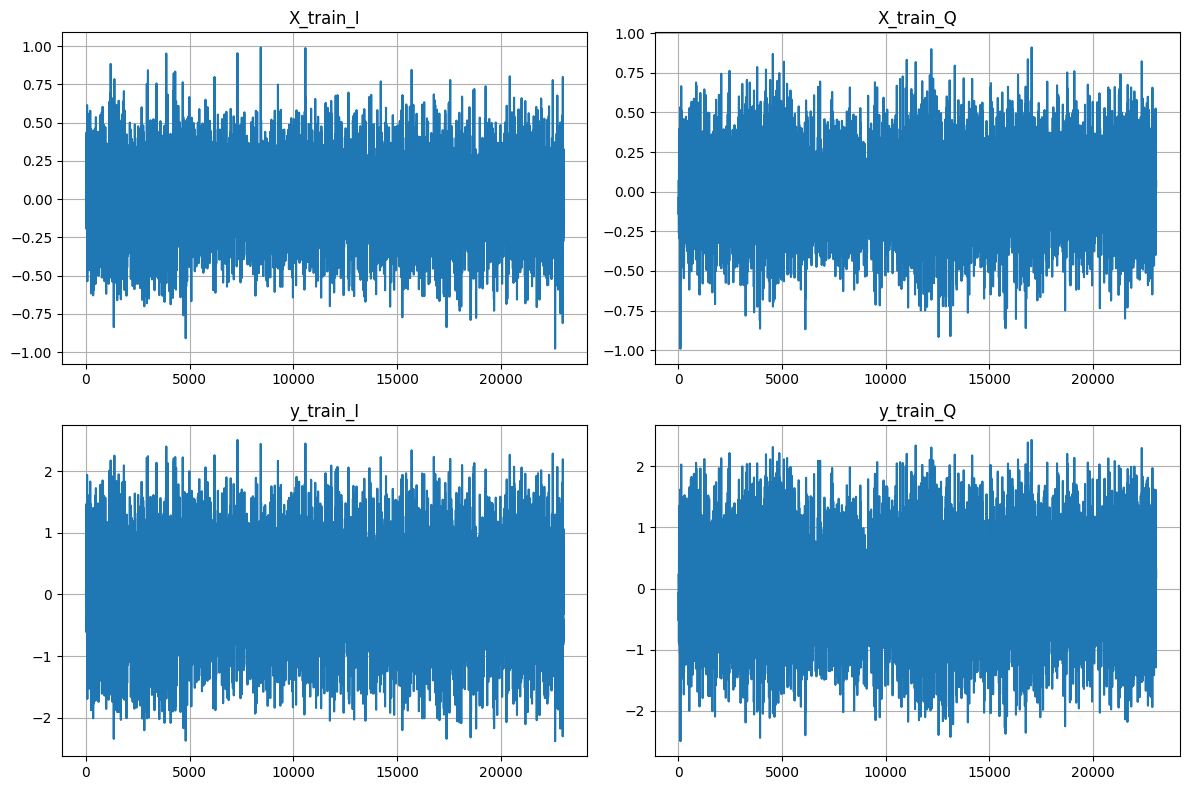

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(X_train_I)
plt.title('X_train_I')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(X_train_Q)
plt.title('X_train_Q')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(y_train_I)
plt.title('y_train_I')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(y_train_Q)
plt.title('y_train_Q')
plt.grid(True)

plt.tight_layout()
plt.show()

##Расчет среднего коэффициента усиления

In [ ]:
# Среднее модуля для I компонент
mean_abs_X_I = np.mean(np.abs(X_train_I))
mean_abs_y_I = np.mean(np.abs(y_train_I))

# Среднее модуля для Q компонент
mean_abs_X_Q = np.mean(np.abs(X_train_Q))
mean_abs_y_Q = np.mean(np.abs(y_train_Q))

mult = (mean_abs_y_I + mean_abs_y_Q) / (mean_abs_X_I + mean_abs_X_Q)

print(f"Среднее |X_train_I|: {mean_abs_X_I:.6f}")
print(f"Среднее |y_train_I|: {mean_abs_y_I:.6f}")
print(f"Среднее |X_train_Q|: {mean_abs_X_Q:.6f}")
print(f"Среднее |y_train_Q|: {mean_abs_y_Q:.6f}")
print(f"Среднее усиление: {mult:.6f}")


Среднее |X_train_I|: 0.194290
Среднее |y_train_I|: 0.623554
Среднее |X_train_Q|: 0.195548
Среднее |y_train_Q|: 0.627942
Среднее усиление: 3.210297


##Обучение PA
Две модели для I и Q отдельно

In [ ]:
import numpy as np
import pandas as pd
from chaotic_library import EnhancedESN_FAN
from sklearn.metrics import mean_squared_error, r2_score

# Входные признаки
X_train = np.column_stack([train_input['I'].values, train_input['Q'].values])  # shape (n_samples, 2)
X_test  = np.column_stack([test_input['I'].values,  test_input['Q'].values])

# Целевые значения отдельно для I и Q
y_train_I = train_output['I'].values  # shape (n_samples,)
y_train_Q = train_output['Q'].values
y_test_I  = test_output['I'].values
y_test_Q  = test_output['Q'].values

print(f"X_train shape: {X_train.shape}")  # (n_samples, 2)
print(f"y_train_I shape: {y_train_I.shape}")

# Создание двух моделей
params = {
    'input_dim': 2,            # два входных признака: I_input и Q_input
    'reservoir_size': 800,
    'spectral_radius': 0.95,
    'sparsity': 0.1,
    'ridge_alpha': 1e-2,
    'leaking_rate': 0.3,
    'poly_order': 2,
    'fan_terms': 8,
    'clip_value': 3.0,
}

esn_I = EnhancedESN_FAN(random_state=42, **params)
esn_Q = EnhancedESN_FAN(random_state=43, **params)

# Обучение
print("Обучение сети для I выхода...")
esn_I.fit(X_train, y_train_I)

print("Обучение сети для Q выхода...")
esn_Q.fit(X_train, y_train_Q)

# Оценка модели
y_pred_I = esn_I.predict(X_test)
y_pred_Q = esn_Q.predict(X_test)

mse_I = mean_squared_error(y_test_I, y_pred_I)
r2_I  = r2_score(y_test_I, y_pred_I)
mse_Q = mean_squared_error(y_test_Q, y_pred_Q)
r2_Q  = r2_score(y_test_Q, y_pred_Q)

print("\n=== Результаты ===")
print(f"I выход: MSE = {mse_I:.6f}, R² = {r2_I:.6f}")
print(f"Q выход: MSE = {mse_Q:.6f}, R² = {r2_Q:.6f}")

results = pd.DataFrame({
    'True_I': y_test_I,
    'Pred_I': y_pred_I,
    'True_Q': y_test_Q,
    'Pred_Q': y_pred_Q
})
results.to_csv('predictions.csv', index=False)
print("Предсказания сохранены в predictions.csv")

X_train shape: (23040, 2)
y_train_I shape: (23040,)
Обучение сети для I выхода...
Обучение сети для Q выхода...

=== Результаты ===
I выход: MSE = 0.000396, R² = 0.999431
Q выход: MSE = 0.000529, R² = 0.999202
Предсказания сохранены в predictions.csv


##Обучение DPD

DPD учиться давать тот сигнал, который при проходе через PA будет равен исходному (поданному в DPD умнженому на коэффициент)

In [ ]:
coeff = mult  # посчитано как среднее усиление без DPD

# Данные для обучения DPD
X_dpd_train = np.column_stack([y_train_I / coeff, y_train_Q / coeff])
X_dpd_test  = np.column_stack([y_test_I  / coeff, y_test_Q  / coeff])

# Цели DPD – реальный вход PA, соответствующий этому выходу
y_dpd_train_I = train_input['I'].values
y_dpd_train_Q = train_input['Q'].values
y_dpd_test_I  = test_input['I'].values
y_dpd_test_Q  = test_input['Q'].values

# Создание и обучение моделей
dpd_params = {
    'input_dim': 2,
    'reservoir_size': 600,
    'spectral_radius': 0.9,
    'sparsity': 0.1,
    'ridge_alpha': 1e-2,
    'leaking_rate': 0.3,
    'poly_order': 2,
    'fan_terms': 8,
    'clip_value': 3.0,
}

dpd_I = EnhancedESN_FAN(random_state=100, **dpd_params)
dpd_Q = EnhancedESN_FAN(random_state=101, **dpd_params)

print("\nОбучение DPD для I-компонента...")
dpd_I.fit(X_dpd_train, y_dpd_train_I)

print("Обучение DPD для Q-компонента...")
dpd_Q.fit(X_dpd_train, y_dpd_train_Q)

# Проверка получившейся связки DPD и PA
# Предсказание предыскажённого сигнала
v_pred_I = dpd_I.predict(X_dpd_test)
v_pred_Q = dpd_Q.predict(X_dpd_test)

# Подача предыскажённого сигнала на модель PA
pa_input_pred = np.column_stack([v_pred_I, v_pred_Q])
pa_out_pred_I = esn_I.predict(pa_input_pred)
pa_out_pred_Q = esn_Q.predict(pa_input_pred)

# Сравнение с целевым выходом PA (который должен быть усилен в coeff раз)
target_I = y_test_I
target_Q = y_test_Q

mse_dpd_I = mean_squared_error(target_I, pa_out_pred_I)
r2_dpd_I  = r2_score(target_I, pa_out_pred_I)
mse_dpd_Q = mean_squared_error(target_Q, pa_out_pred_Q)
r2_dpd_Q  = r2_score(target_Q, pa_out_pred_Q)

print("\n=== Результаты каскада DPD → PA (усиление x3) ===")
print(f"I выход: MSE = {mse_dpd_I:.6f}, R² = {r2_dpd_I:.6f}")
print(f"Q выход: MSE = {mse_dpd_Q:.6f}, R² = {r2_dpd_Q:.6f}")

# Сохранение результатов
cascade_results = pd.DataFrame({
    'Desired_I': target_I,
    'Cascade_out_I': pa_out_pred_I,
    'Desired_Q': target_Q,
    'Cascade_out_Q': pa_out_pred_Q,
    'DPD_out_I': v_pred_I,
    'DPD_out_Q': v_pred_Q
})
cascade_results.to_csv('cascade_predictions.csv', index=False)
print("Результаты каскада сохранены в cascade_predictions.csv")


Обучение DPD для I-компонента...
Обучение DPD для Q-компонента...

=== Результаты каскада DPD → PA (усиление x3) ===
I выход: MSE = 0.000246, R² = 0.999646
Q выход: MSE = 0.000594, R² = 0.999104
Результаты каскада сохранены в cascade_predictions.csv


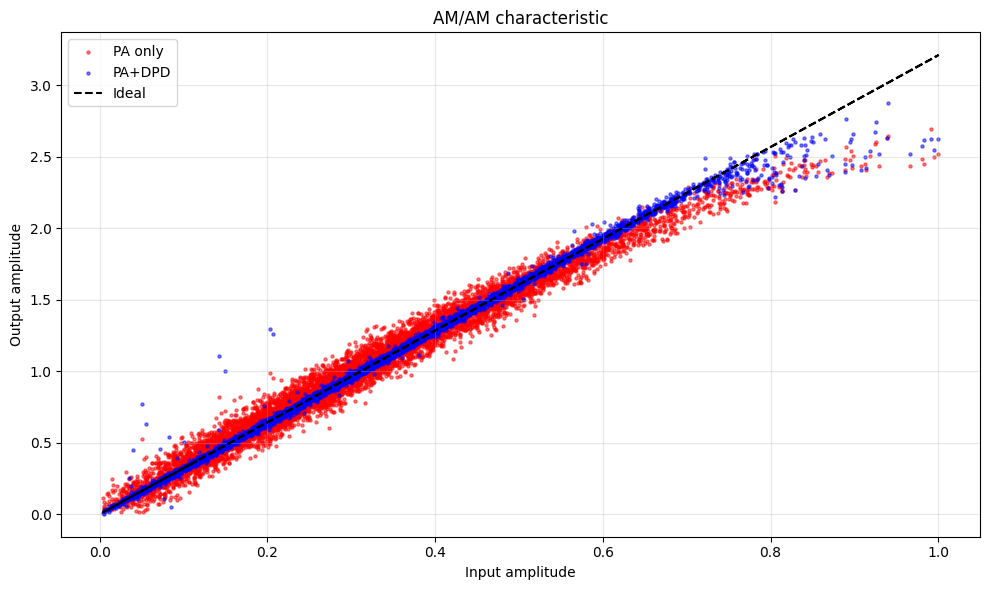

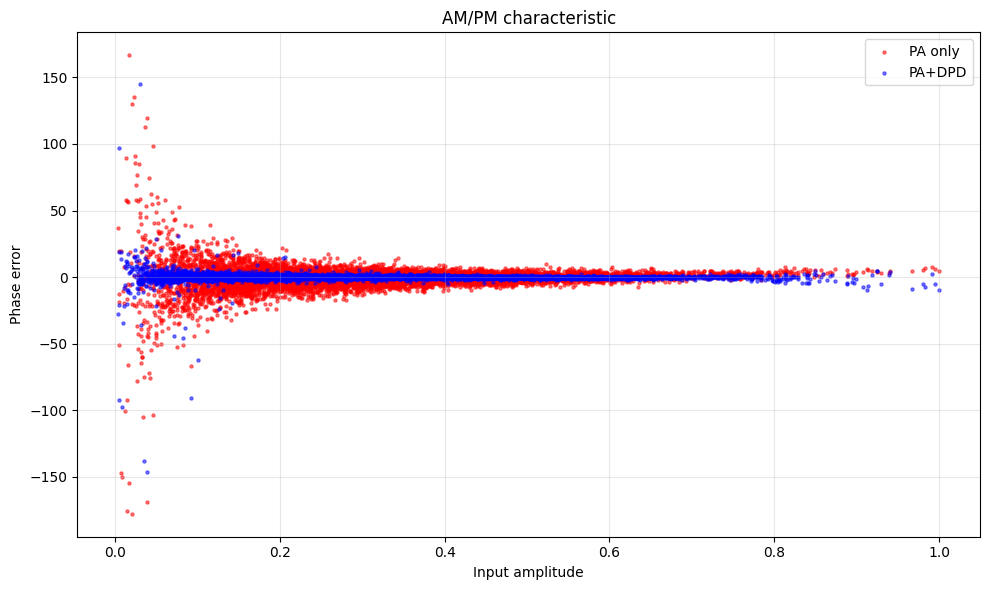

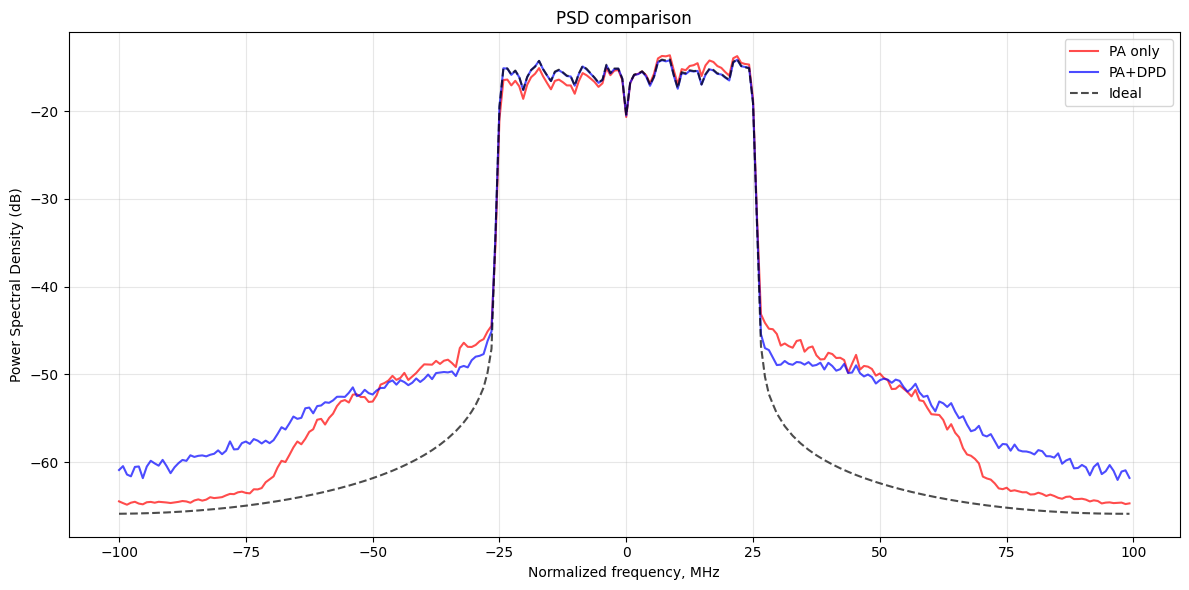

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import welch
import numpy as np

# Входной сигнал:
x_in_I = X_test[:, 0]
x_in_Q = X_test[:, 1]
x_complex = x_in_I + 1j*x_in_Q
amp_x = np.abs(x_complex)
phase_x = np.angle(x_complex)

# 2. PA only:
pa_only_complex = y_pred_I + 1j*y_pred_Q

# 3. PA+DPD:
v_dpd_I = dpd_I.predict(X_test)
v_dpd_Q = dpd_Q.predict(X_test)
v_dpd = np.column_stack([v_dpd_I, v_dpd_Q])

pa_dpd_out_I = esn_I.predict(v_dpd)
pa_dpd_out_Q = esn_Q.predict(v_dpd)
pa_dpd_complex = pa_dpd_out_I + 1j*pa_dpd_out_Q

# 4. Идеальный линейный выход
ideal_complex = coeff * x_complex
amp_ideal = np.abs(ideal_complex)
phase_ideal = np.angle(ideal_complex)

# График 1: AM/AM
plt.figure(figsize=(10, 6))
plt.scatter(amp_x, np.abs(pa_only_complex), c='red', s=5, alpha=0.5, label='PA only')
plt.scatter(amp_x, np.abs(pa_dpd_complex), c='blue', s=5, alpha=0.5, label='PA+DPD')
plt.plot(amp_x, amp_ideal, 'k--', lw=1.5, label='Ideal')
plt.xlabel('Input amplitude')
plt.ylabel('Output amplitude')
plt.title('AM/AM characteristic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('amam_comparison_Xtest.png', dpi=150)
plt.show()

# График 2: AM/PM
# Фазовая ошибка:
phase_err_pa = np.angle(pa_only_complex) - phase_x
phase_err_dpd = np.angle(pa_dpd_complex) - phase_x

# Приводим к [-π, π]
phase_err_pa = np.arctan2(np.sin(phase_err_pa), np.cos(phase_err_pa))
phase_err_dpd = np.arctan2(np.sin(phase_err_dpd), np.cos(phase_err_dpd))

plt.figure(figsize=(10, 6))
plt.scatter(amp_x, np.rad2deg(phase_err_pa), c='red', s=5, alpha=0.5, label='PA only')
plt.scatter(amp_x, np.rad2deg(phase_err_dpd), c='blue', s=5, alpha=0.5, label='PA+DPD')
plt.xlabel('Input amplitude')
plt.ylabel('Phase error')
plt.title('AM/PM characteristic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ampm_comparison_Xtest.png', dpi=150)
plt.show()

# График 3: PSD
fs = 200
nperseg = min(256, len(x_complex))

f_pa, psd_pa = welch(pa_only_complex, fs=fs, nperseg=nperseg, return_onesided=False)
f_dpd, psd_dpd = welch(pa_dpd_complex, fs=fs, nperseg=nperseg, return_onesided=False)
f_ideal, psd_ideal = welch(ideal_complex, fs=fs, nperseg=nperseg, return_onesided=False)

# Перевод в dB
eps = 1e-12
psd_pa_db = 10 * np.log10(psd_pa + eps)
psd_dpd_db = 10 * np.log10(psd_dpd + eps)
psd_ideal_db = 10 * np.log10(psd_ideal + eps)

f_pa = np.fft.fftshift(f_pa)
psd_pa_db = np.fft.fftshift(psd_pa_db)
f_dpd = np.fft.fftshift(f_dpd)
psd_dpd_db = np.fft.fftshift(psd_dpd_db)
f_ideal = np.fft.fftshift(f_ideal)
psd_ideal_db = np.fft.fftshift(psd_ideal_db)

plt.figure(figsize=(12, 6))
plt.plot(f_pa, psd_pa_db, 'red', alpha=0.7, label='PA only')
plt.plot(f_dpd, psd_dpd_db, 'blue', alpha=0.7, label='PA+DPD')
plt.plot(f_ideal, psd_ideal_db, 'k--', alpha=0.7, label='Ideal')
plt.xlabel('Normalized frequency, MHz')
plt.ylabel('Power Spectral Density (dB)')
plt.title('PSD comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('psd_comparison_Xtest.png', dpi=150)
plt.show()

Центр спектра корректируется очень хорошо, но самые крайние значения с DPD получаются хуже чем без. Возможно в этом сигнале их слишком мало, поэтому при обучении такие значения слабо учитываются. Если подать на вход сигнал, где не будет слабых частот, то DPD улучшит весь спектр. Показано в следующем примере

## Построение графиков для уже искаженного сигнала
Тут DPD однозначно улучшает результат

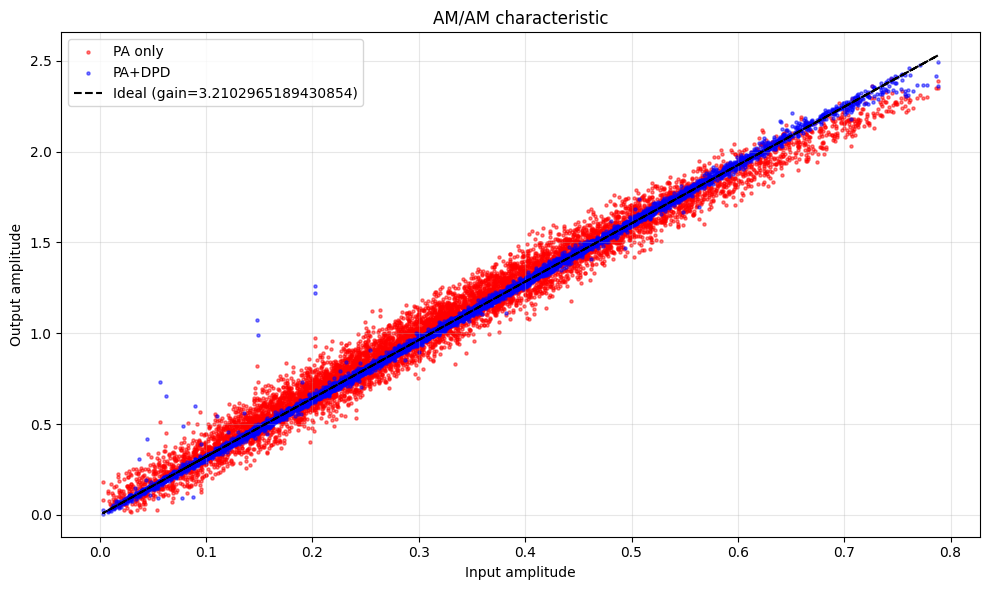

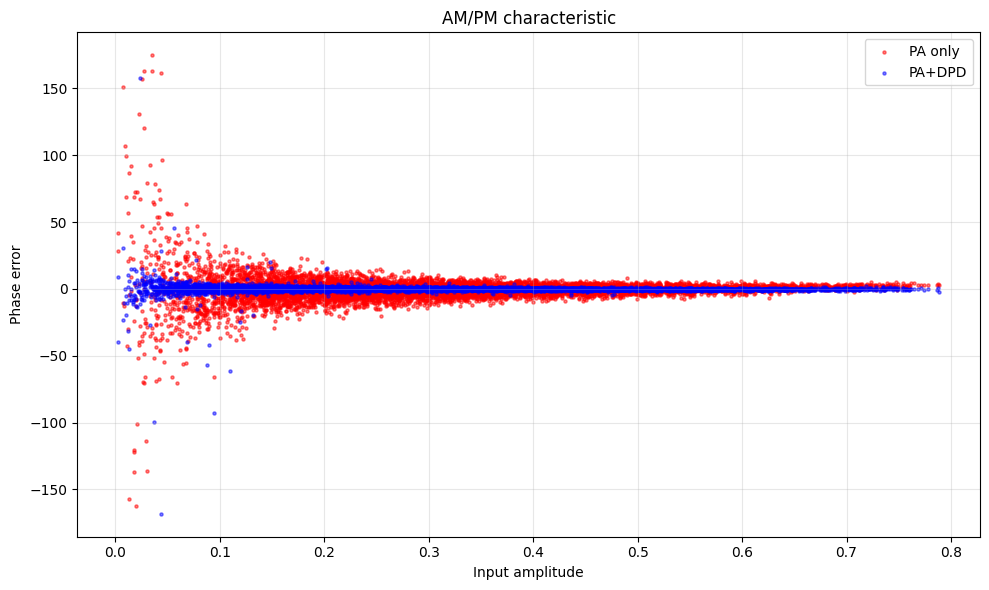

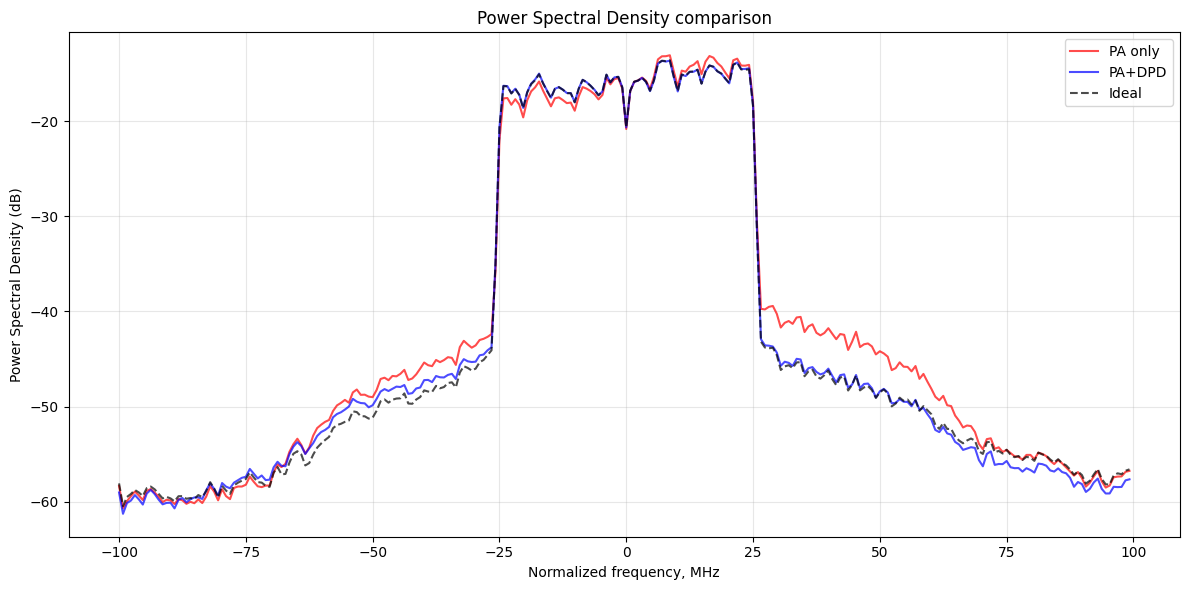

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import welch
import numpy as np

# Входной сигнал
u_I = y_test_I / coeff
u_Q = y_test_Q / coeff
u_complex = u_I + 1j*u_Q
amp_u = np.abs(u_complex)
phase_u = np.angle(u_complex)

# PA only
pa_only_input = np.column_stack([u_I, u_Q])
pa_only_out_I = esn_I.predict(pa_only_input)
pa_only_out_Q = esn_Q.predict(pa_only_input)
pa_only_complex = pa_only_out_I + 1j*pa_only_out_Q
amp_pa_only = np.abs(pa_only_complex)
phase_pa_only = np.angle(pa_only_complex)

# PA+DPD
pa_dpd_complex = pa_out_pred_I + 1j*pa_out_pred_Q
amp_pa_dpd = np.abs(pa_dpd_complex)
phase_pa_dpd = np.angle(pa_dpd_complex)

# Идеальный усиленный сигнал
ideal_complex = u_complex * coeff
amp_ideal = np.abs(ideal_complex)
phase_ideal = np.angle(ideal_complex)

# График 1: AM/AM
plt.figure(figsize=(10, 6))
plt.scatter(amp_u, amp_pa_only, c='red', s=5, alpha=0.5, label='PA only')
plt.scatter(amp_u, amp_pa_dpd, c='blue', s=5, alpha=0.5, label='PA+DPD')
plt.plot(amp_u, amp_ideal, 'k--', lw=1.5, label=f'Ideal (gain={coeff})')
plt.xlabel('Input amplitude')
plt.ylabel('Output amplitude')
plt.title('AM/AM characteristic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('amam_comparison.png', dpi=150)
plt.show()

# График 2: AM/PM
# Фазовая ошибка
phase_error_pa_only = np.angle(pa_only_complex) - phase_u
phase_error_pa_dpd   = np.angle(pa_dpd_complex) - phase_u

# Привод к диапазону [-pi, pi]
phase_error_pa_only = np.arctan2(np.sin(phase_error_pa_only), np.cos(phase_error_pa_only))
phase_error_pa_dpd   = np.arctan2(np.sin(phase_error_pa_dpd), np.cos(phase_error_pa_dpd))

plt.figure(figsize=(10, 6))
plt.scatter(amp_u, np.rad2deg(phase_error_pa_only), c='red', s=5, alpha=0.5, label='PA only')
plt.scatter(amp_u, np.rad2deg(phase_error_pa_dpd), c='blue', s=5, alpha=0.5, label='PA+DPD')
plt.xlabel('Input amplitude')
plt.ylabel('Phase error')
plt.title('AM/PM characteristic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ampm_comparison.png', dpi=150)
plt.show()

# График 3: PSD
fs = 200
nperseg = min(256, len(y_test_I))
f_pa_only, psd_pa_only = welch(pa_only_complex, fs=fs, nperseg=nperseg, return_onesided=False)
f_pa_dpd, psd_pa_dpd     = welch(pa_dpd_complex, fs=fs, nperseg=nperseg, return_onesided=False)
f_ideal, psd_ideal       = welch(ideal_complex, fs=fs, nperseg=nperseg, return_onesided=False)

# Перевод в dB
psd_pa_only_db = 10 * np.log10(psd_pa_only + 1e-12)
psd_pa_dpd_db  = 10 * np.log10(psd_pa_dpd + 1e-12)
psd_ideal_db   = 10 * np.log10(psd_ideal + 1e-12)

f_pa_only = np.fft.fftshift(f_pa_only)
psd_pa_only_db = np.fft.fftshift(psd_pa_only_db)
f_pa_dpd = np.fft.fftshift(f_pa_dpd)
psd_pa_dpd_db = np.fft.fftshift(psd_pa_dpd_db)
f_ideal = np.fft.fftshift(f_ideal)
psd_ideal_db = np.fft.fftshift(psd_ideal_db)

plt.figure(figsize=(12, 6))
plt.plot(f_pa_only, psd_pa_only_db, 'red', alpha=0.7, label='PA only')
plt.plot(f_pa_dpd, psd_pa_dpd_db, 'blue', alpha=0.7, label='PA+DPD')
plt.plot(f_ideal, psd_ideal_db, 'k--', alpha=0.7, label='Ideal')
plt.xlabel('Normalized frequency, MHz')
plt.ylabel('Power Spectral Density (dB)')
plt.title('Power Spectral Density comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('psd_comparison.png', dpi=150)
plt.show()

Тут видно, что с таким сигналом DPD справляется намного лучше

В дальнейшем планируются эксперименты с различными способами обучения DPD, что должно позволить улучшить работу DPD на частотах с низкой амплитудой в спектре. Так же сейчас DPD и PA работаю в экспериментально режиме (на вход подается сразу целый массив данных). Будет реализован рабочий режим, в котором DPD будет каждой единице приходящего сигнала сразу сопостовлять выходной сигнал, ведь на практике это должно работать именно так